#### **This script evaluates the results for softunion and softunion null**

In [1]:
import pandas as pd

In [2]:
files = {
    'egypt_uae_082019_1': {
        'pvalue_edges': 'egypt_uae_082019_1_tweets_softunion_merged_edges_0.05.csv',
        'quantile_edges': 'egypt_uae_082019_1_tweets_softunion_merged_edges_0.95.csv',
        'campaign': 'egypt_uae_082019_1_tweets',
        
        # 'cohashtag': 'egypt_uae_082019_1_tweets_softunion_cohashtag_edges_0.95.csv',
        # 'coretweet': 'egypt_uae_082019_1_tweets_softunion_coretweet_edges_0.95.csv',
        # 'coretweetusers': 'egypt_uae_082019_1_tweets_softunion_coretweetusers_edges_0.95.csv',
        # 'coword': 'egypt_uae_082019_1_tweets_softunion_coword_edges_0.95.csv',
        
        # 'p_cohashtag': 'egypt_uae_082019_1_tweets_softunion_null_cohashtag_edges_0.95.csv',
        # 'p_coretweet': 'egypt_uae_082019_1_tweets_softunion_null_coretweet_edges_0.95.csv',
        # 'p_coretweetusers': 'egypt_uae_082019_1_tweets_softunion_null_coretweetusers_edges_0.95.csv',
        # 'p_coword': 'egypt_uae_082019_1_tweets_softunion_null_coword_edges_0.95.csv',
    },
    # 'uae': {
    #     'quantile_edges': 'uae_082019_1_tweets_softunion_merged_edges_0.95.csv',
    #     'pvalue_edges': 'quantile_edges
    # },
    'ecuador_082019_1': {
        'pvalue_edges': 'ecuador_082019_1_tweets_softunion_null_merged_edges_0.05.csv',
        'campaign': 'ecuador_082019_1_tweets',
        'quantile_edges': 'ecuador_082019_1_tweets_softunion_merged_edges_0.95.csv'
    },
    'armenia': {
        'pvalue_edges': 'armenia_202012_tweets_softunion_null_merged_edges_0.05.csv',
        'quantile_edges': 'armenia_202012_tweets_softunion_merged_edges_0.95.csv',
        'campaign': 'armenia_202012_tweets'
    },
    'thailand': {
        'quantile_edges': 'thailand_092020_tweets_softunion_merged_edges_0.95.csv',
        'pvalue_edges': 'thailand_092020_tweets_softunion_null_merged_edges_0.05.csv',
        'campaign': 'thailand_092020_tweets'
    },
     'iranian': {
        'quantile_edges': 'iranian_tweets_softunion_merged_edges_0.95.csv',
        'pvalue_edges': 'iranian_tweets_softunion_null_merged_edges_0.05.csv',
        'campaign': 'iranian_tweets'
    },
}

In [3]:
path = '/N/slate/potem/project/coordinationz/Outputs/Tables/'

In [4]:
io_path = '/N/project/INCAS/new_parse/'

#### **Check control nodes**

In [5]:
df_control = pd.read_pickle(
    '/N/project/INCAS/new_parse/control/thailand_092020_tweets_control.pkl.gz'
)

In [6]:
df_control.columns

Index(['tweetid', 'tweet_text', 'in_reply_to_tweetid', 'in_reply_to_userid',
       'tweet_time', 'tweet_client_name', 'tweet_language', 'hashtags',
       'user_mentions', 'urls', 'is_retweet', 'retweet_tweetid',
       'retweet_userid', 'userid', 'user_profile_image_url',
       'user_screen_name', 'account_creation_date', 'user_verified',
       'user_protected', 'user_profile_description', 'user_profile_entites',
       'user_profile_url', 'user_display_name', 'follower_count',
       'following_count', 'user_profile_status_count',
       'user_profile_listed_count', 'user_profile_favourites_count',
       'user_reported_geo', 'user_reported_coordinates',
       'user_reported_location'],
      dtype='object')

In [7]:
df_control['userid'].nunique()

2549

# **The number of nodes does not in edge file does not match in node file!!!**

In [5]:
def load_org_data(campaign,files=files):

    print(campaign)

    io_path = '/N/project/INCAS/new_parse/'
    
    io_file = io_path + 'io/'+ files[campaign]['campaign'] + '_io.pkl.gz'
    control_file = io_path + 'control/' + files[campaign]['campaign'] + '_control.pkl.gz'

    print(io_file)
    print(control_file)
    import os

    if os.path.exists(io_file) == False:
        print(io_file, '   does not exist!!')
        return

    if os.path.exists(control_file) == False:
        print(control_file, '  does not exists!!!')
        return 
    
    df_org_io =  pd.read_pickle(io_file)
    df_org_io['y_org'] = 1
    
    df_org_control =  pd.read_pickle(control_file)
    df_org_control['y_org'] = 0
    
    df_org = pd.concat([df_org_io, df_org_control],
                       ignore_index=True
                      )
    print(df_org['y_org'].unique())

    df_org['userid'] = df_org['userid'].astype(str)

    return df_org

In [6]:
campaign = 'egypt_uae_082019_1'

df_org = load_org_data(campaign)

egypt_uae_082019_1
/N/project/INCAS/new_parse/io/egypt_uae_082019_1_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/egypt_uae_082019_1_tweets_control.pkl.gz
[1 0]


In [8]:
def individual_indicator(campaign, look_up, x):
    import os
    
    print(x)
    
    if x == 'merged':
        pvalue_path = path + files[campaign]['pvalue_edges']
        quant_path = path + files[campaign]['quantile_edges']
    else:
        pvalue_path = path + files[campaign]['p_' + x]
        quant_path = path + files[campaign][x]

        if os.path.exists(pvalue_path) == False:
            print(pvalue_path, '   does not exist!!')
            return
    
        if os.path.exists(quant_path) == False:
            print(quant_path, '  does not exists!!!')
            return 

    print(pvalue_path)
    print(quant_path)
    
    df_pvalue = pd.read_csv(pvalue_path, dtype={
         'source_id': str,
        'target_id': str
    })
    df_quant = pd.read_csv(quant_path,  dtype={
         'source_id': str,
        'target_id': str
    })

    # df_pvalue = df_pvalue.astype({
    #     'source_id': str,
    #     'target_id': str
    # })

    # df_quant = df_quant.astype({
    #     'source_id': str,
    #     'target_id': str
    # })

    return df_pvalue, df_quant

In [9]:
df_pvalue, df_quant = individual_indicator(campaign, files, 'merged')

merged
/N/slate/potem/project/coordinationz/Outputs/Tables/egypt_uae_082019_1_tweets_softunion_merged_edges_0.05.csv
/N/slate/potem/project/coordinationz/Outputs/Tables/egypt_uae_082019_1_tweets_softunion_merged_edges_0.95.csv


In [10]:
df_pvalue.head()

,source_id,target_id,pvalue,similarity,Type,weight
0,3359730304,3422848211,1.624147e-03,0.775319,cohashtag-coretweetusers,0.998376
1,3359730304,4063226111,1.124972e-03,0.739037,cohashtag,0.998875
2,3359730304,3054201266,1.874906e-08,0.775361,cohashtag-coretweet,1.000000
3,3359730304,1057362688148455424,6.249531e-10,0.830816,cohashtag-coretweet-coretweetusers,1.000000
4,3359730304,1057330268103688198,4.556022e-07,0.796882,cohashtag-coretweet,1.000000


In [11]:
df_pvalue['pvalue'].max()

np.float64(0.0468286204147113)

In [13]:
# df_pvalue.loc[(df_pvalue['target_id'] == '1057362688148455424')]

In [14]:
# df_quant.head()

#### **Get node probability**

In [61]:
def node_mean_edge_probability(df_edges):
    # Combine 'source' and 'target' into a single column of 'nodes' and repeat 'probability'
    nodes_prob = pd.concat([
        df_edges[['source_id', 'pvalue']].rename(columns={'source_id': 'node'}),
        df_edges[['target_id', 'pvalue']].rename(columns={'target_id': 'node'})
    ])
    
    # Calculate mean probability for each node
    node_level_probs = nodes_prob.groupby('node')['pvalue'].mean().reset_index()
    # node_level_probs['pvalue'] = 1 - node_level_probs['pvalue']
    
    return node_level_probs


def node_mean_edge_probability_for_quantile(df_edges):
    nodes_prob = pd.concat([
        df_edges[['source_id', 'quantile']].rename(columns={'source_id': 'node'}),
        df_edges[['target_id', 'quantile']].rename(columns={'target_id': 'node'})
    ])
    
    # Calculate mean probability for each node
    node_level_probs = nodes_prob.groupby('node')['quantile'].mean().reset_index()
    
    return node_level_probs

In [62]:
df_nodes = node_mean_edge_probability(df_pvalue)

In [63]:
df_nodes.head()

,node,pvalue
0,1023186421727690752,0.000025
1,1050297379394600961,0.000025
2,1050435431106367488,0.000025
3,1055448603458596864,0.000025
4,1066560463444488193,0.000025


In [65]:
# df_nodes['pvalue'].unique()

#### **Add the node label**

In [66]:
def add_labels(df_org, df_nodes):
    df_org_grp = df_org.groupby(['userid', 'y_org']).first().reset_index()
    # df_org_grp['y_pred'] = 1
    # df_org_grp.loc[~(df_org_grp['userid'].isin(df_nodes['node'])), 'y_pred'] = 0

    if 'pvalue' in df_nodes.columns:
        column = 'pvalue'
    else:
        column = 'quantile'
        
    df_merge = df_org_grp[['userid', 'y_org']].merge(df_nodes[['node', column]],
                                                     left_on='userid',
                                                     right_on='node'
                                                    )
    return df_merge

def load_labels(df_org, df_edge):
    list_nodes = list(set(df_edge['source_id']).union(set(df_edge['target_id'])))
    df_label = pd.DataFrame(data=list_nodes,
                            columns=['user_id']
                           )

    print(df_org['y_org'].unique())
    
    df_label = df_label.astype({
        'user_id': str
    })

    print('not matching data:' , 
          len(df_label.loc[~(df_label['user_id'].isin(df_org['userid']))])
         )

    #### **Considering all dataset**
    df_org_grp = df_org.groupby(['userid', 'y_org']).first().reset_index()

    print(df_org_grp['y_org'].unique())
    
    df_org_grp['y_pred'] = 1
    # df_org_grp.loc[df_org_grp['userid'].isin(df_label['user_id']), 'y_pred'] = 1
    df_org_grp.loc[~(df_org_grp['userid'].isin(df_label['user_id'])), 'y_pred'] = 0

    #### **Considering only the filtered dataset**
    # df_label['y_pred'] = 1
    # df_label['y_org'] = 0

    # df_label = df_label.merge(df_org_grp[['userid', 'y_org']],
    #                           left_on='user_id',
    #                           right_on='userid',
    #                           how='left'
    #                          )
    # print(df_label['y_org'].unique())
    
    # df_label.loc[df_label['user_id'].isin(df_org_grp['userid']), 'y_org'] = df_org_grp['y_org']

    return df_org_grp #, df_label

In [26]:
# df_pvalue.columns

In [27]:
# df_org_grp = load_labels(df_org, df_pvalue)

In [20]:
df_org_grp = add_labels(df_org, df_nodes)

In [21]:
df_org_grp.columns

Index(['userid', 'y_org', 'node', 'pvalue'], dtype='object')

In [22]:
df_org_grp.head()

,userid,y_org,node,pvalue
0,1057330268103688198,1,1057330268103688198,0.997628
1,1057337073873678339,1,1057337073873678339,0.999523
2,1057354985892130817,1,1057354985892130817,0.999975
3,1057362688148455424,1,1057362688148455424,0.999756
4,1057365183004336128,1,1057365183004336128,0.999991


In [23]:
df_org_grp['y_org'].unique()

array([1, 0])

#### **AUC curve**

In [24]:
from sklearn.metrics import roc_auc_score

roc_auc_score(df_org_grp['y_org'], df_org_grp['pvalue'])

np.float64(0.4892979452054794)

In [241]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

def metric(df,
           y_ground='y_org', 
           y_pred='y_pred'
          ):

    precision = precision_score(df[y_ground],
                                df[y_pred]
                               )
    print(f"Precision: {precision}")
    
    # Calculate recall
    recall = recall_score(df[y_ground],
                          df[y_pred]
                         )
    print(f"Recall: {recall}")
    
    # Calculate F1-score
    f1 = f1_score(df[y_ground],
                  df[y_pred]
                 )
    print(f"F1-Score: {f1}")

    report = classification_report(df[y_ground], df[y_pred])
    print(report)


# def auc_pvalue_threshold():
    

In [25]:
# df_org_grp, df_label

In [56]:
 # metric(df_org_grp,
 #       y_ground='y_org', 
 #       y_pred='y_pred'
 #      )

In [57]:
 # metric(df_label,
 #       y_ground='y_org', 
 #       y_pred='y_pred'
 #      )

In [245]:
def loop_indicator(indicator):
    indicators = ['merged', 'cohashtag', 'coretweet' , 'coretweetusers', 'coword']

    for x in indicators:
        df_pvalue, df_quant = individual_indicator(campaign, look_up, x)

    return df_pvalue, df_quant

#### **Softunion: Run all the campaigns**

In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Function to calculate AUC-ROC and AUC-PR with p-value or quantile thresholds
def auc_roc_pr_analysis(scores, labels, thresholds, threshold_type='pvalue'):
    """
    Analyze AUC-ROC and AUC-PR using either p-value or quantile as thresholds.
    
    Parameters:
    - scores: array-like, predicted scores or probabilities.
    - labels: array-like, true binary labels (0 or 1).
    - thresholds: list, thresholds for p-value or quantile.
    - threshold_type: str, 'pvalue' (lower means positive) or 'quantile' (higher means positive).
    
    Returns:
    - auc_roc_score: float, computed AUC-ROC.
    - auc_pr_score: float, computed AUC-PR.
    """
    tpr_list = []
    fpr_list = []
    precision_list = []
    recall_list = []
    
    for threshold in thresholds:
        if threshold_type == 'pvalue':
            predictions = np.where(scores <= threshold, 1, 0)  # P-value: lower is positive
        elif threshold_type == 'quantile':
            # quantile_value = np.quantile(scores, threshold)
            predictions = np.where(scores >= threshold, 1, 0)  # Quantile: higher is positive
        else:
            raise ValueError("threshold_type must be 'pvalue' or 'quantile'")
        
        # True Positives, False Positives, etc.
        tp = np.sum((predictions == 1) & (labels == 1))
        fp = np.sum((predictions == 1) & (labels == 0))
        tn = np.sum((predictions == 0) & (labels == 0))
        fn = np.sum((predictions == 0) & (labels == 1))
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # 1 - Specificity
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tpr  # Recall is the same as TPR
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
        precision_list.append(precision)
        recall_list.append(recall)
    
    # Sort FPR and TPR for ROC curve
    fpr_list, tpr_list = zip(*sorted(zip(fpr_list, tpr_list)))
    auc_roc_score = auc(fpr_list, tpr_list)
    
    # Sort Precision and Recall for PR curve
    recall_list, precision_list = zip(*sorted(zip(recall_list, precision_list)))
    auc_pr_score = auc(recall_list, precision_list)
    
    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_list, tpr_list, label=f'ROC Curve (AUC = {auc_roc_score:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Threshold Type: {threshold_type.capitalize()}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()
    
    # Plot Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall_list, precision_list, label=f'PR Curve (AUC = {auc_pr_score:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - Threshold Type: {threshold_type.capitalize()}')
    plt.legend(loc='lower left')
    plt.grid()
    plt.show()
    
    return auc_roc_score, auc_pr_score


 Campaign : egypt_uae_082019_1
egypt_uae_082019_1
/N/project/INCAS/new_parse/io/egypt_uae_082019_1_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/egypt_uae_082019_1_tweets_control.pkl.gz
[1 0]
merged
/N/slate/potem/project/coordinationz/Outputs/Tables/egypt_uae_082019_1_tweets_softunion_merged_edges_0.05.csv
/N/slate/potem/project/coordinationz/Outputs/Tables/egypt_uae_082019_1_tweets_softunion_merged_edges_0.95.csv
Min pvalue : 6.249687511718358e-10


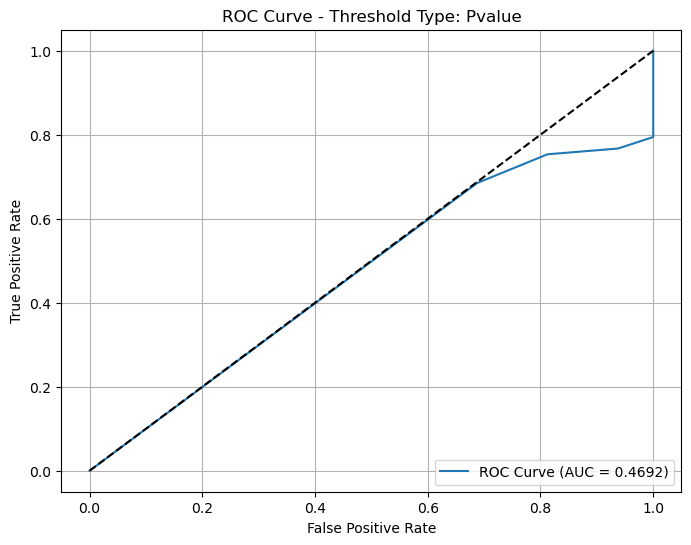

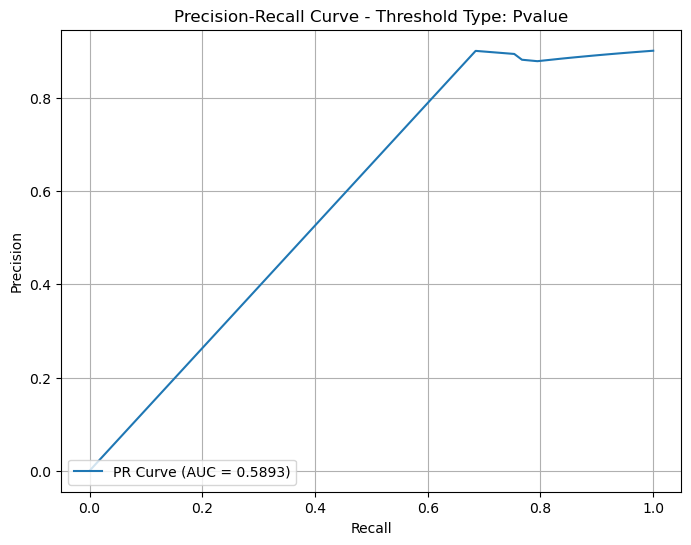

AUC-ROC (P-value thresholds): 0.4692
AUC-PR (P-value thresholds): 0.5893
Quantile min : 0.958715162966462


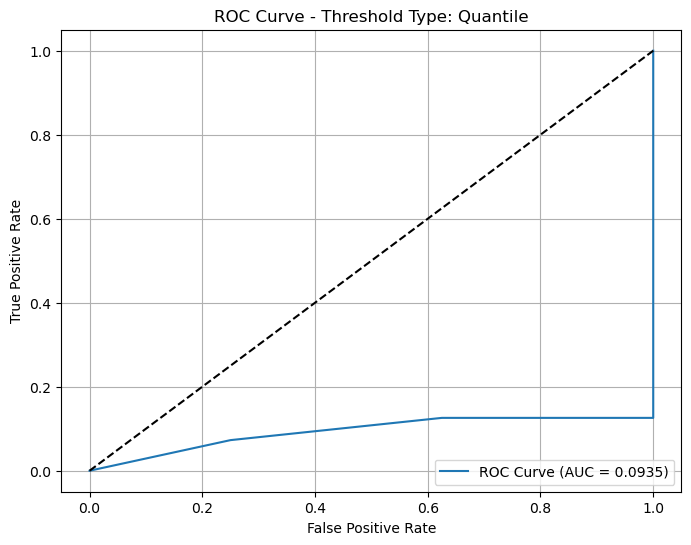

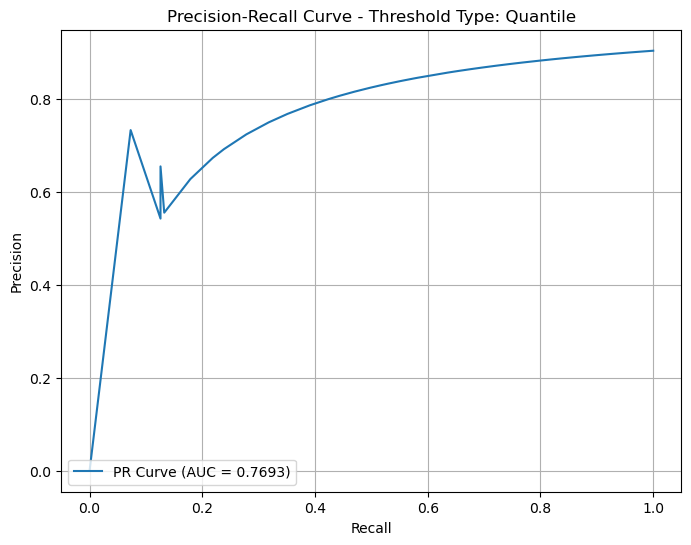

AUC-ROC (Quantile thresholds): 0.0935
AUC-PR (Quantile thresholds): 0.7693

 Campaign : ecuador_082019_1
ecuador_082019_1
/N/project/INCAS/new_parse/io/ecuador_082019_1_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/ecuador_082019_1_tweets_control.pkl.gz
[1 0]
merged
/N/slate/potem/project/coordinationz/Outputs/Tables/ecuador_082019_1_tweets_softunion_null_merged_edges_0.05.csv
/N/slate/potem/project/coordinationz/Outputs/Tables/ecuador_082019_1_tweets_softunion_merged_edges_0.95.csv
Min pvalue : 1.9819136774434138e-19


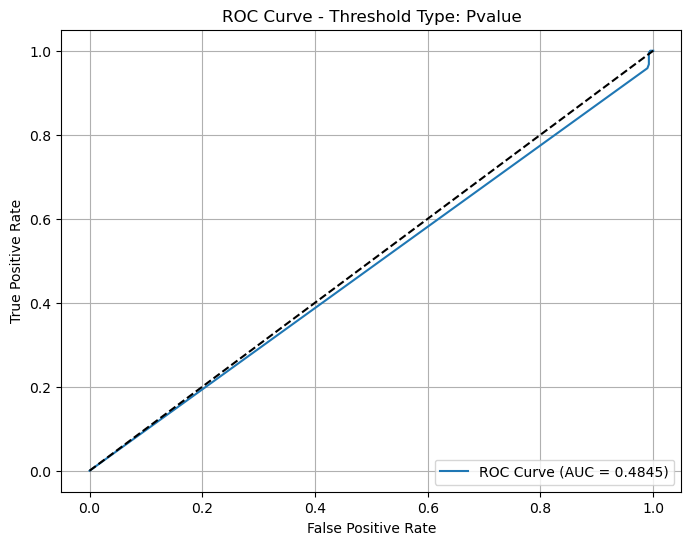

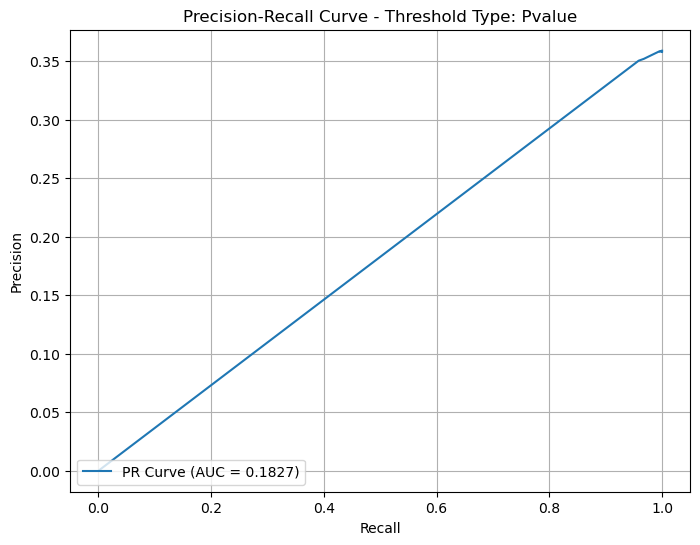

AUC-ROC (P-value thresholds): 0.4845
AUC-PR (P-value thresholds): 0.1827
Quantile min : 0.9928422626996422


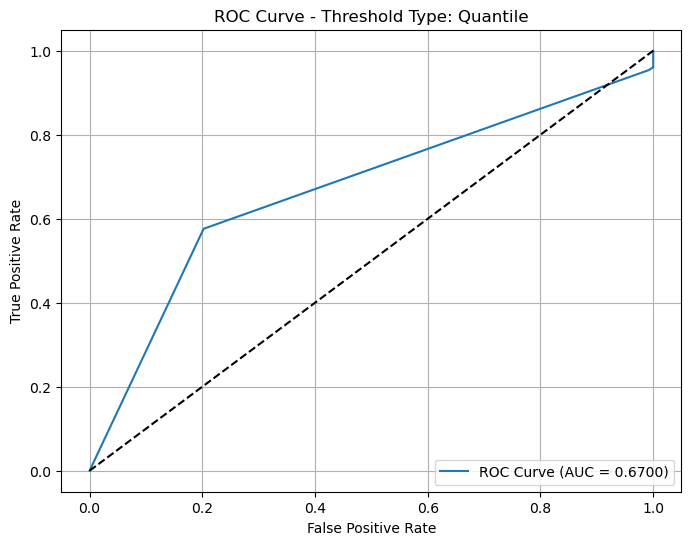

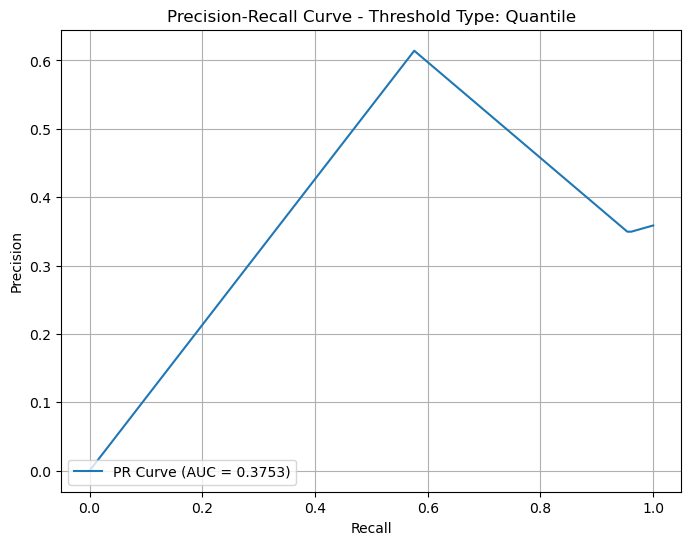

AUC-ROC (Quantile thresholds): 0.6700
AUC-PR (Quantile thresholds): 0.3753

 Campaign : armenia
armenia
/N/project/INCAS/new_parse/io/armenia_202012_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/armenia_202012_tweets_control.pkl.gz
[1 0]
merged
/N/slate/potem/project/coordinationz/Outputs/Tables/armenia_202012_tweets_softunion_null_merged_edges_0.05.csv
/N/slate/potem/project/coordinationz/Outputs/Tables/armenia_202012_tweets_softunion_merged_edges_0.95.csv
Min pvalue : 3.5721427924161823e-06


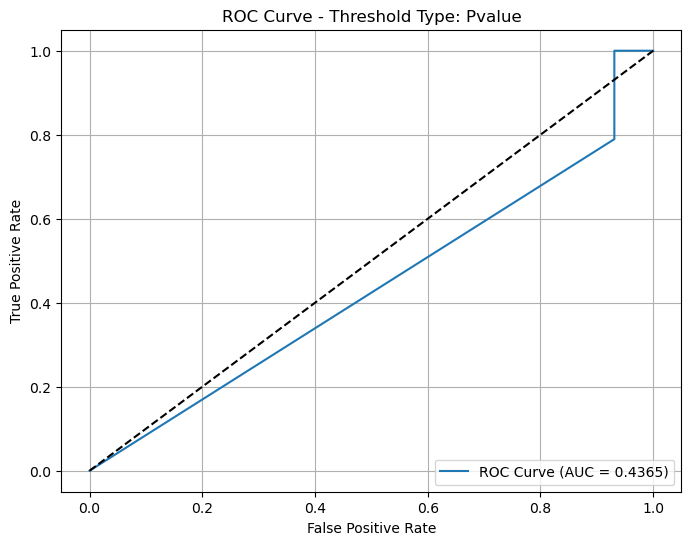

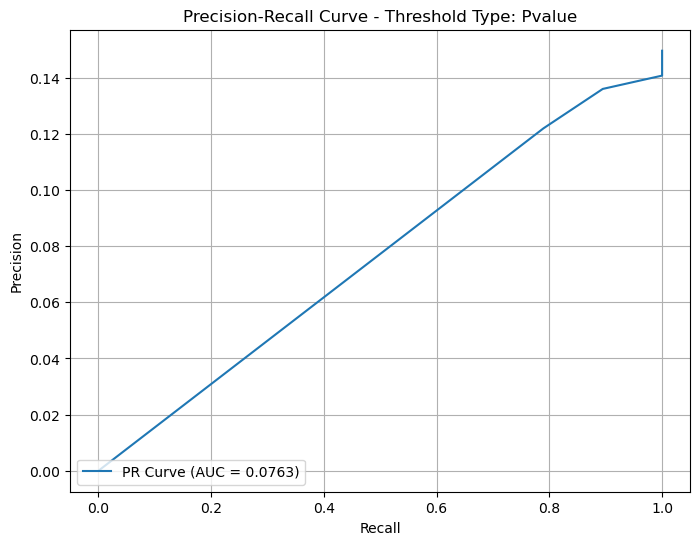

AUC-ROC (P-value thresholds): 0.4365
AUC-PR (P-value thresholds): 0.0763
Quantile min : 0.9975358829231684


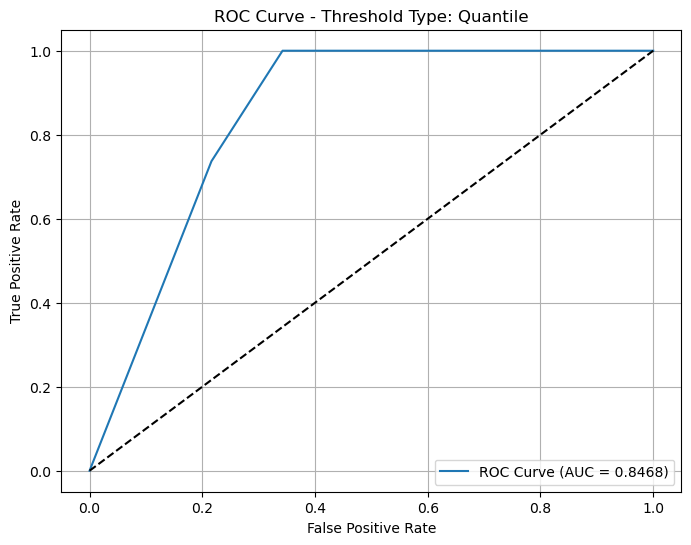

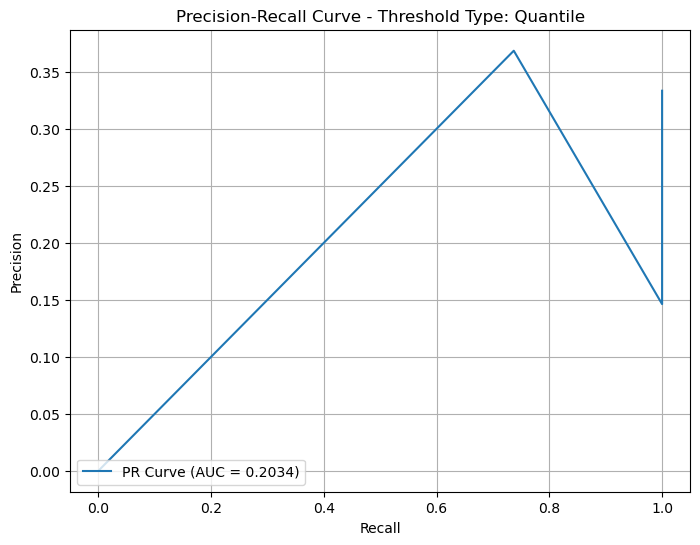

AUC-ROC (Quantile thresholds): 0.8468
AUC-PR (Quantile thresholds): 0.2034

 Campaign : thailand
thailand
/N/project/INCAS/new_parse/io/thailand_092020_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/thailand_092020_tweets_control.pkl.gz
[1 0]
merged
/N/slate/potem/project/coordinationz/Outputs/Tables/thailand_092020_tweets_softunion_null_merged_edges_0.05.csv
/N/slate/potem/project/coordinationz/Outputs/Tables/thailand_092020_tweets_softunion_merged_edges_0.95.csv
Min pvalue : 1.2499791674478775e-05


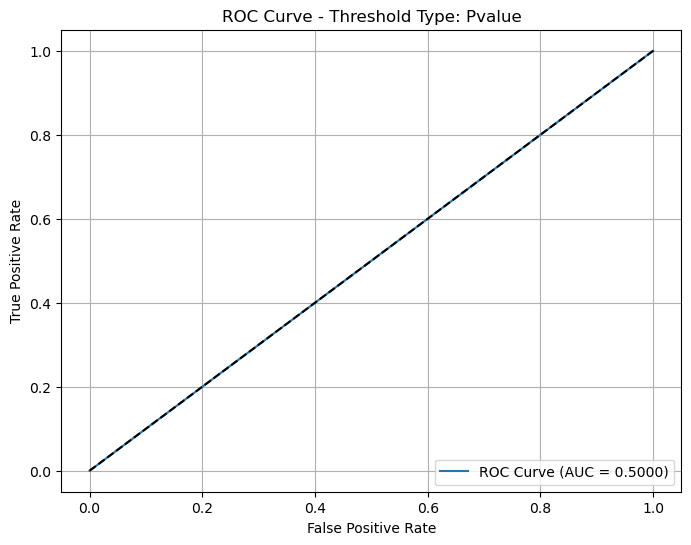

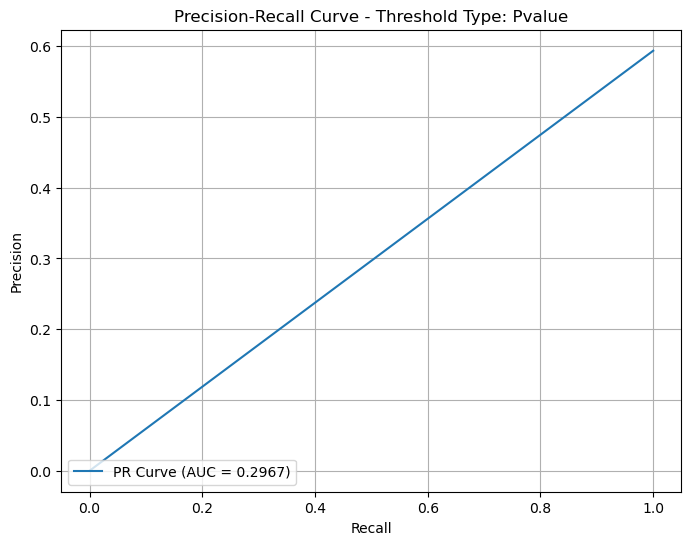

AUC-ROC (P-value thresholds): 0.5000
AUC-PR (P-value thresholds): 0.2967
Quantile min : 0.9859690532389196


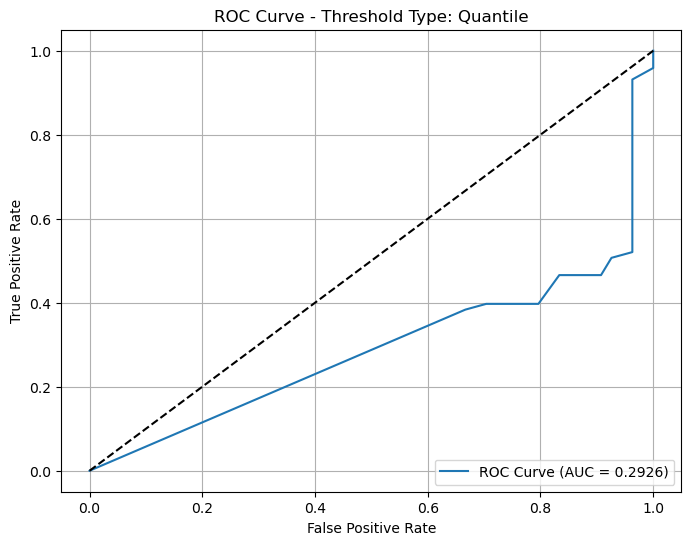

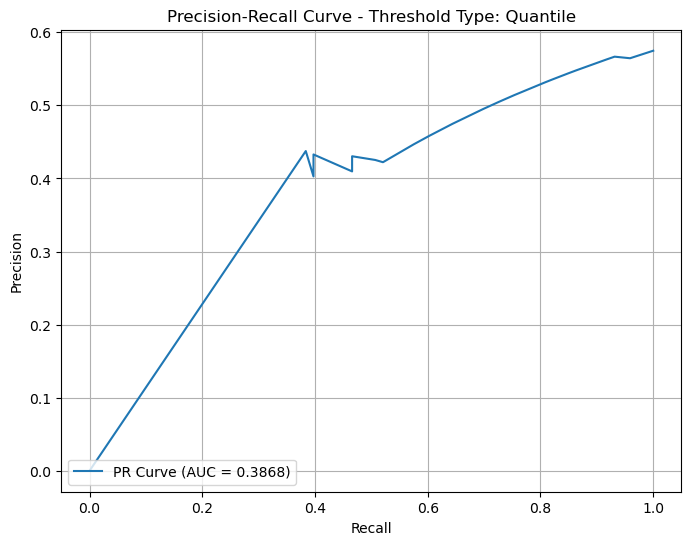

AUC-ROC (Quantile thresholds): 0.2926
AUC-PR (Quantile thresholds): 0.3868

 Campaign : iranian
iranian
/N/project/INCAS/new_parse/io/iranian_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/iranian_tweets_control.pkl.gz
[1 0]
merged
/N/slate/potem/project/coordinationz/Outputs/Tables/iranian_tweets_softunion_null_merged_edges_0.05.csv
/N/slate/potem/project/coordinationz/Outputs/Tables/iranian_tweets_softunion_merged_edges_0.95.csv
Min pvalue : 1.5623828183591307e-14


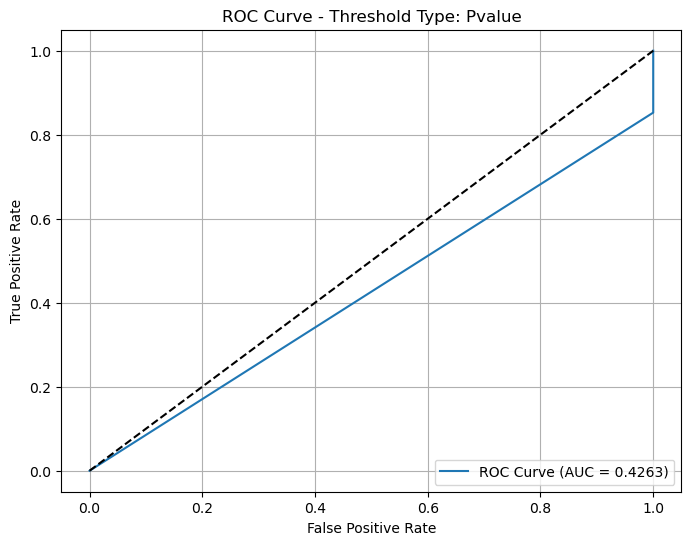

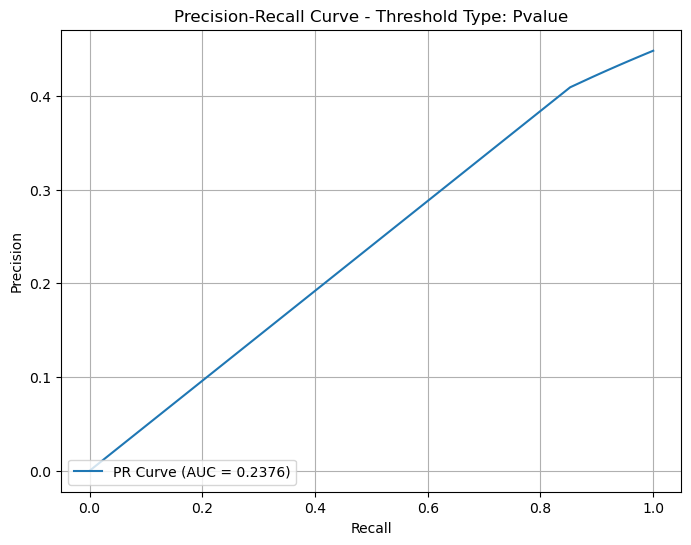

AUC-ROC (P-value thresholds): 0.4263
AUC-PR (P-value thresholds): 0.2376
Quantile min : 0.9585659712018807


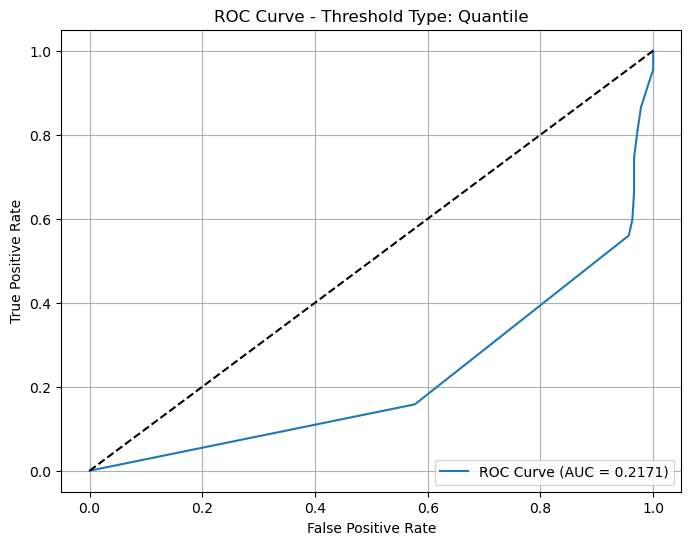

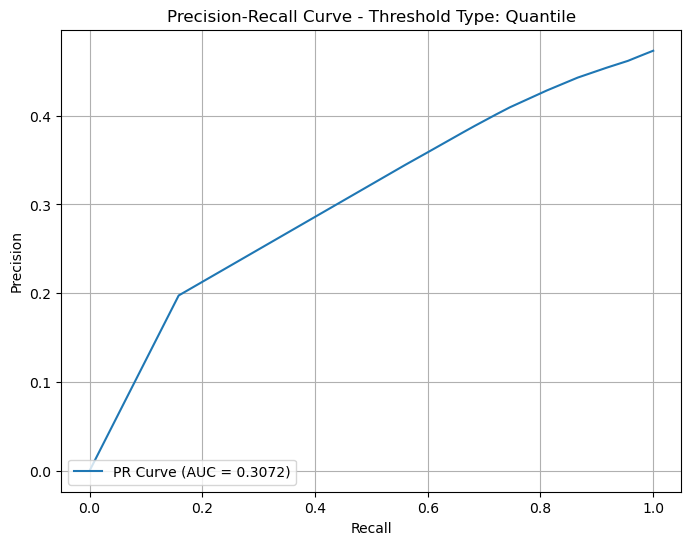

AUC-ROC (Quantile thresholds): 0.2171
AUC-PR (Quantile thresholds): 0.3072


In [74]:
for campaign in files:
    # if campaign != 'thailand':
    #     continue

    print('\n Campaign :', campaign)
    df_org = load_org_data(campaign)
    df_pvalue, df_quant = individual_indicator(campaign, files, 'merged')

    # Sample Data: Replace with real scores and labels
    df_nodes = node_mean_edge_probability(df_pvalue)
    df_org_grp = add_labels(df_org, df_nodes)
    scores = df_org_grp['pvalue']  # Example: Predicted scores between 0 and 1
    labels =  df_org_grp['y_org']  # Example: True binary labels (0 or 1)

    print('Min pvalue :', df_org_grp['pvalue'].min())
    
    # P-value analysis
    pvalue_thresholds = np.linspace(0.0, 0.051, 100)  # Example p-value thresholds
    auc_roc_pvalue, auc_pr_pvalue = auc_roc_pr_analysis(scores, labels, pvalue_thresholds, threshold_type='pvalue')
    print(f"AUC-ROC (P-value thresholds): {auc_roc_pvalue:.4f}")
    print(f"AUC-PR (P-value thresholds): {auc_pr_pvalue:.4f}")

    # Quantile analysis
    df_nodes = node_mean_edge_probability_for_quantile(df_quant)
    df_org_grp = add_labels(df_org, df_nodes)
    scores = df_org_grp['quantile']  # Example: Predicted scores between 0 and 1
    labels =  df_org_grp['y_org']  # Example: True binary labels (0 or 1)
    
    print('Quantile min :', df_org_grp['quantile'].min())
    quantile_thresholds = np.linspace(0.95, 1.01, 100)  # Top 10% quantiles
    auc_roc_quantile, auc_pr_quantile = auc_roc_pr_analysis(scores, labels, 
                                                            quantile_thresholds, 
                                                            threshold_type='quantile'
                                                           )
    print(f"AUC-ROC (Quantile thresholds): {auc_roc_quantile:.4f}")
    print(f"AUC-PR (Quantile thresholds): {auc_pr_quantile:.4f}")

#### **Union**

In [70]:
path = '/N/slate/potem/project/coordinationz/Outputs/Tables/'

In [71]:
union_files = {
    'thailand_092020_tweets': {
        # 'pvalue_edges': 'thailand_092020_tweets_union_merged_edges_0.95.csv',
        'quantile_edges': 'thailand_092020_tweets_union_merged_edges_0.95.csv',
        'campaign': 'thailand_092020_tweets',
    },
      'egypt_uae_082019_1': {
        # 'pvalue_edges': 'egypt_uae_082019_1_tweets_softunion_merged_edges_0.05.csv',
        'quantile_edges': 'egypt_uae_082019_1_tweets_union_merged_edges_0.95.csv',
        'campaign': 'egypt_uae_082019_1_tweets',
    },
    # 'uae': {
    #     'quantile_edges': 'uae_082019_1_tweets_softunion_merged_edges_0.95.csv',
    #     'pvalue_edges': 'quantile_edges
    # },
    'ecuador_082019_1': {
        # 'pvalue_edges': 'ecuador_082019_1_tweets_softunion_null_merged_edges_0.05.csv',
        'campaign': 'ecuador_082019_1_tweets',
        'quantile_edges': 'ecuador_082019_1_tweets_union_merged_edges_0.95.csv'
    },
    'armenia': {
        # 'pvalue_edges': 'armenia_202012_tweets_softunion_null_merged_edges_0.05.csv',
        'quantile_edges': 'armenia_202012_tweets_union_merged_edges_0.95.csv',
        'campaign': 'armenia_202012_tweets'
    },
     'iranian': {
        'quantile_edges': 'iranian_tweets_union_merged_edges_0.95.csv',
        # 'pvalue_edges': 'iranian_tweets_softunion_null_merged_edges_0.05.csv',
        'campaign': 'iranian_tweets'
    },
}


def load_union_file(campaign, files):
    quantile_file = path + files[campaign]['quantile_edges']
    
    df_quantile = pd.read_csv(quantile_file)

    print(df_quantile.head())

    df_quantile = df_quantile.astype({
        'source_id': str,
        'target_id': str
    })
    
    return df_quantile


 Campaign : thailand_092020_tweets
thailand_092020_tweets
/N/project/INCAS/new_parse/io/thailand_092020_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/thailand_092020_tweets_control.pkl.gz
[1 0]
             source_id            target_id  similarity  \
0           3815702113           3859845433    0.963257   
1  1215151302348398592  1215152247207628800    0.970830   
2  1215152247207628800  1215145116953788416    0.961712   
3  1230323175436611584  1230313994587496449    0.958049   
4  1230323175436611584  1230346893806301184    0.958049   

                       Type  quantile    weight  
0                 cohashtag  1.000000  0.963257  
1  coretweet-coretweetusers  0.999977  0.970830  
2            coretweetusers  0.999999  0.961712  
3                 coretweet  0.999998  0.958049  
4                 coretweet  0.999998  0.958049  
                  node  quantile
0  1214752079064911872  0.999891
1  1214760170116354050  0.999945
2  1214762046924845057  0.999998
3  121514511

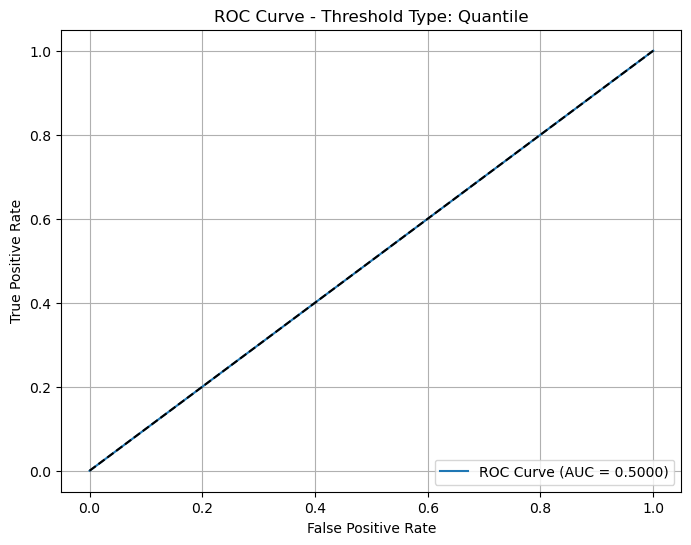

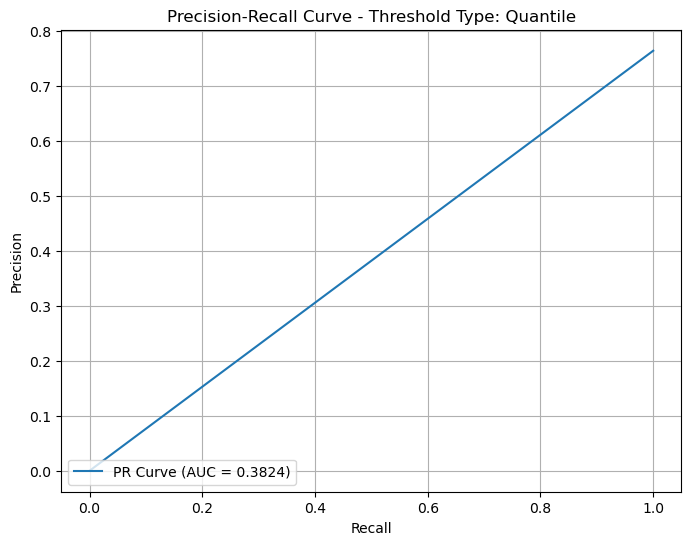

AUC-ROC (Quantile thresholds): 0.5000
AUC-PR (Quantile thresholds): 0.3824

 Campaign : egypt_uae_082019_1
egypt_uae_082019_1
/N/project/INCAS/new_parse/io/egypt_uae_082019_1_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/egypt_uae_082019_1_tweets_control.pkl.gz
[1 0]
            source_id           target_id  similarity  \
0          4919411469          4919443673    0.951426   
1          4919411469          4919457101    0.981815   
2          4919443673          4919457101    0.958274   
3          4919443673  767429025165901824    0.951009   
4  765910922086998016          4923639676    0.984419   

                       Type  quantile    weight  
0  cohashtag-coretweetusers  0.996368  0.951426  
1  cohashtag-coretweetusers  0.996699  0.981815  
2            coretweetusers  0.998062  0.958274  
3            coretweetusers  0.997795  0.951009  
4  cohashtag-coretweetusers  0.998533  0.984419  
                  node  quantile
0  1057370157432164352  0.996699
1  10573810014905

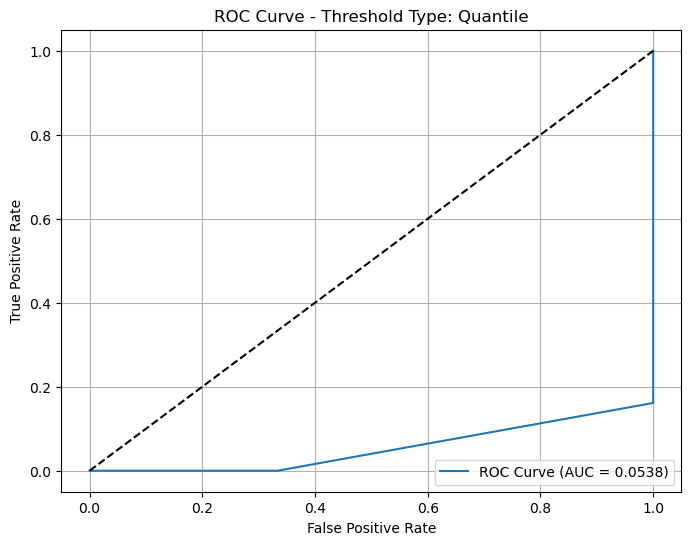

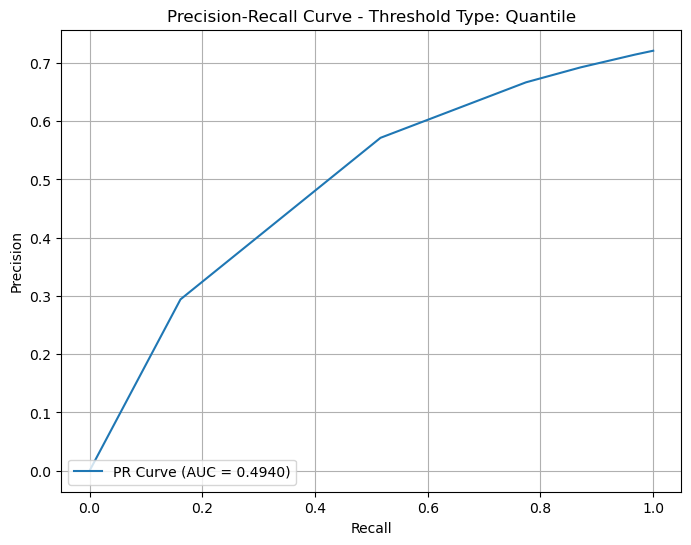

AUC-ROC (Quantile thresholds): 0.0538
AUC-PR (Quantile thresholds): 0.4940

 Campaign : ecuador_082019_1
ecuador_082019_1
/N/project/INCAS/new_parse/io/ecuador_082019_1_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/ecuador_082019_1_tweets_control.pkl.gz
[1 0]
    source_id   target_id  similarity       Type  quantile    weight
0   375502041   397560740    0.959076  cohashtag  0.999802  0.959076
1  1523066148   924454980    0.986742  cohashtag  0.999902  0.986742
2   923664576   924454980    0.955981  cohashtag  0.999800  0.955981
3   371394255  1424263549    0.999998  cohashtag  0.999953  0.999998
4   371394255  2975658322    0.999990  cohashtag  0.999926  0.999990
                  node  quantile
0  1003085410506100736  0.999768
1  1008065047132811264  0.999780
2  1008119518789554182  0.999932
3  1008370573607661568  0.999790
4  1008404034754154496  0.999908
0.996796959423811


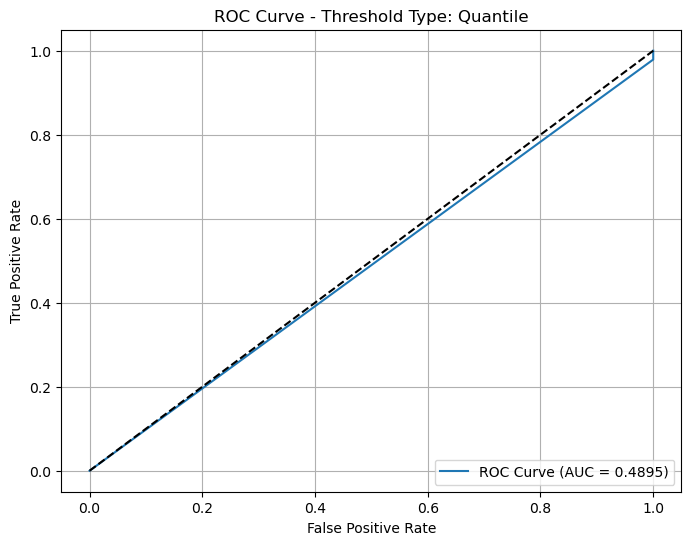

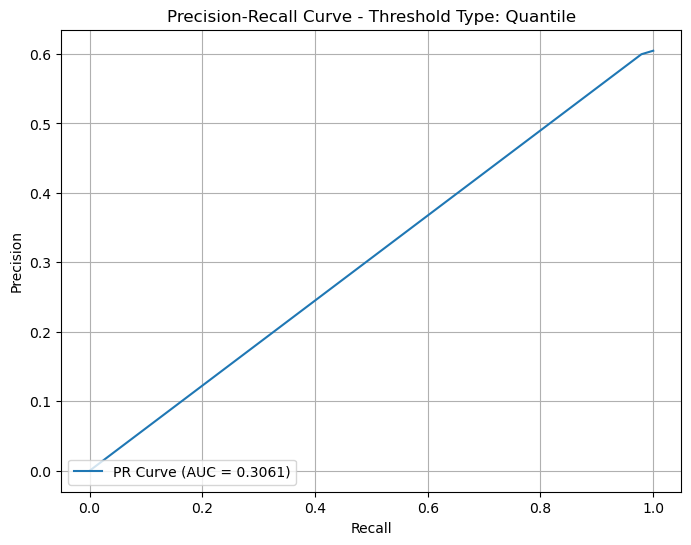

AUC-ROC (Quantile thresholds): 0.4895
AUC-PR (Quantile thresholds): 0.3061

 Campaign : armenia
armenia
/N/project/INCAS/new_parse/io/armenia_202012_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/armenia_202012_tweets_control.pkl.gz
[1 0]
             source_id            target_id  similarity              Type  \
0           4044235875           3978680777    0.998920  cohashtag-coword   
1  1099241323679412229  1098837578667749377    0.967780         cohashtag   
2  1098837578667749377  1098865327969091584    0.959853         cohashtag   
3  1098831656801222656  1098563811026657280    0.980127         cohashtag   
4  1098831656801222656  1098551258783367175    0.970437         cohashtag   

   quantile    weight  
0  0.999959  0.998920  
1  0.999613  0.967780  
2  0.999512  0.959853  
3  0.999756  0.980127  
4  0.999634  0.970437  
                  node  quantile
0           1053556404  1.000000
1  1098548077487669249  0.999744
2  1098551258783367175  0.999552
3  10985638110266

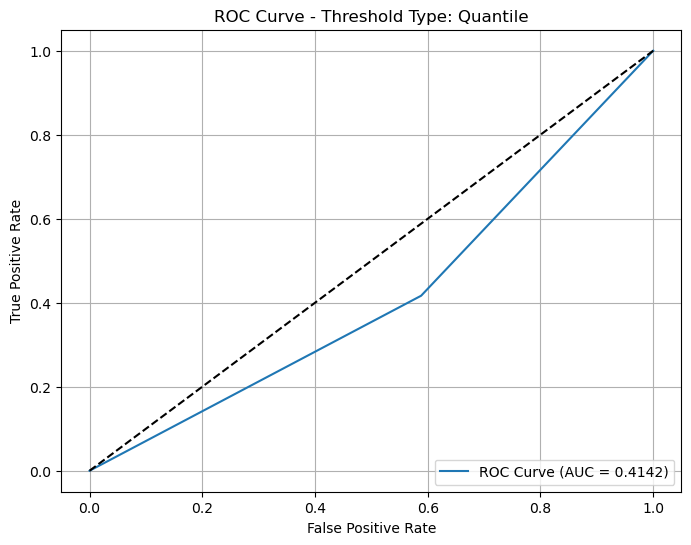

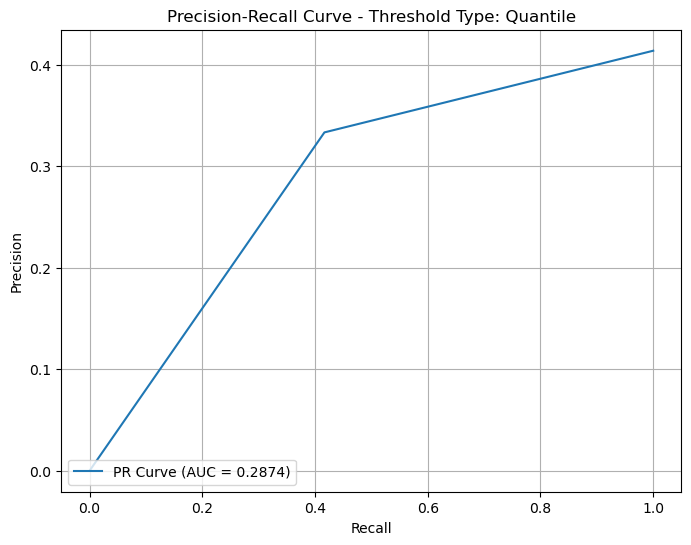

AUC-ROC (Quantile thresholds): 0.4142
AUC-PR (Quantile thresholds): 0.2874

 Campaign : iranian
iranian
/N/project/INCAS/new_parse/io/iranian_tweets_io.pkl.gz
/N/project/INCAS/new_parse/control/iranian_tweets_control.pkl.gz
[1 0]
            source_id           target_id  similarity            Type  \
0          1480654033           574054264    0.974910       cohashtag   
1  869940286868267008  947123669574275072    0.951119  coretweetusers   
2  869940286868267008  883682958351192066    0.953220  coretweetusers   
3  869940286868267008  951008244050415616    0.954602  coretweetusers   
4  869940286868267008  950990269742280704    0.962243  coretweetusers   

   quantile    weight  
0  0.999906  0.974910  
1  0.999826  0.951119  
2  0.999830  0.953220  
3  0.999833  0.954602  
4  0.999845  0.962243  
                  node  quantile
0  1020976953459867649  1.000000
1  1020998852860686336  1.000000
2            105178861  0.999982
3           1064560646  0.999985
4           1085188069

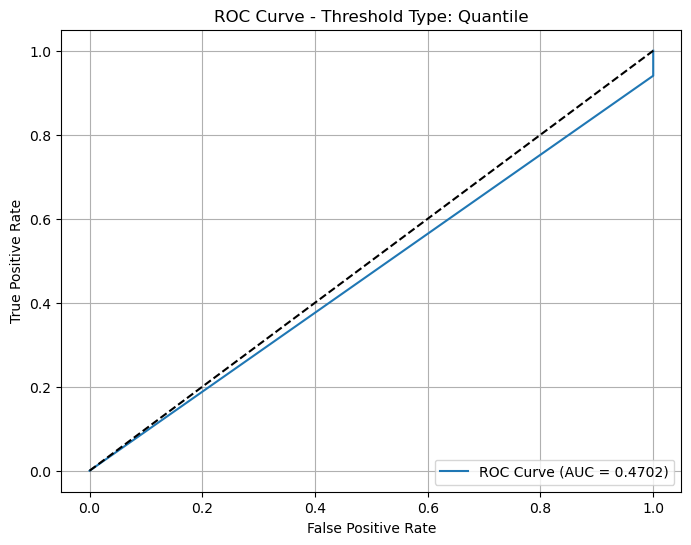

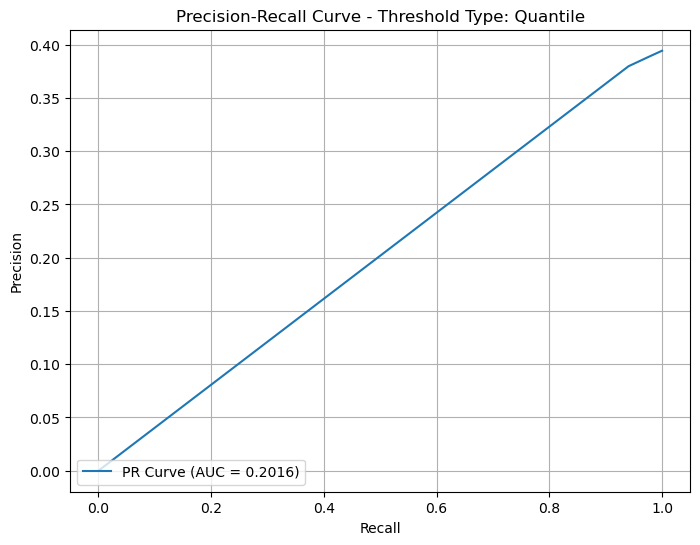

AUC-ROC (Quantile thresholds): 0.4702
AUC-PR (Quantile thresholds): 0.2016


In [75]:
for campaign in union_files:
    # if campaign != 'thailand':
    #     continue

    print('\n Campaign :', campaign)
    
    df_org = load_org_data(campaign, union_files)
    df_quant = load_union_file(campaign, union_files)
    # df_nodes = node_mean_edge_probability(df_pvalue)

    df_nodes = node_mean_edge_probability_for_quantile(df_quant)

    print(df_nodes.head())
    
    df_org_grp = add_labels(df_org, df_nodes)

    # Sample Data: Replace with real scores and labels
    scores = df_org_grp['quantile']  # Example: Predicted scores between 0 and 1
    labels =  df_org_grp['y_org']  # Example: True binary labels (0 or 1)

    # # P-value analysis
    # pvalue_thresholds = np.linspace(0.01, 0.1, 10)  # Example p-value thresholds
    # auc_roc_pvalue, auc_pr_pvalue = auc_roc_pr_analysis(scores, labels, pvalue_thresholds, threshold_type='pvalue')
    # print(f"AUC-ROC (P-value thresholds): {auc_roc_pvalue:.4f}")
    # print(f"AUC-PR (P-value thresholds): {auc_pr_pvalue:.4f}")

    # Quantile analysis
    print(df_org_grp['quantile'].min())
    quantile_thresholds = np.linspace(0.95, 1.01, 100)  # Top 10% quantiles
    auc_roc_quantile, auc_pr_quantile = auc_roc_pr_analysis(scores, labels, quantile_thresholds, threshold_type='quantile')
    print(f"AUC-ROC (Quantile thresholds): {auc_roc_quantile:.4f}")
    print(f"AUC-PR (Quantile thresholds): {auc_pr_quantile:.4f}")